# Non-Homogeneous Hidden Markov Models (NHMM) with Sequenzo - pairfam Activity Dataset

This tutorial demonstrates how to use **Non-Homogeneous Hidden Markov Models (NHMM)** for life course analysis with the Sequenzo package. While the companion mvad tutorial covers standard HMM and MHMM, and the biofam tutorial covers multichannel HMM, this tutorial shows how to incorporate **covariates** that affect transition probabilities.

## About the Dataset

The **pairfam** (Panel Analysis of Intimate Relationships and Family Dynamics) dataset records the **monthly activity status** of **1027 individuals** born in 1971-1973 in Germany, observed over **264 months** (22 years). Each person's trajectory is a sequence of one of eight activity states:

| State | Description |
|-------|-------------|
| 1 | In school / general education |
| 2 | Vocational training / apprenticeship |
| 3 | Higher education / university |
| 4 | Full-time employment |
| 5 | Part-time employment |
| 6 | Parental leave / homemaking |
| 7 | Unemployed |
| 8 | Other (military service, gap year, etc.) |

This is a **single-channel** dataset with **16 background covariates**, including gender, birth year, years of education, East/West Germany, high school attendance, religious participation, and family structure at age 18.

## Why NHMM?

A standard HMM assumes that transition probabilities are **fixed**, which are the same for all individuals and all time points. But in reality, the probability of transitioning from education to employment may depend on:
- **Gender**: Women may be more likely to transition into parental leave.
- **Education level**: More education may lead to different career entry patterns.
- **Region**: East and West Germany had very different labour markets after reunification.

A **Non-Homogeneous HMM** allows transition probabilities to vary as a function of covariates. Instead of a fixed transition matrix A, the NHMM models A(x) where x is a vector of covariates. This lets us ask not just "what are the hidden stages?" but "how do individual characteristics shape the transitions between stages?"

## Research Questions

1. **What are the hidden stages of activity trajectories** over this 22-year window? (Standard HMM as baseline)

2. **Do covariates such as gender, education, and region affect how people transition between activity stages?** Specifically, are women more likely to transition into parental leave? Do people with more education transition differently into the labour market? Do East Germans experience more unemployment? (NHMM)

In this tutorial, we will:
1. Load and prepare the pairfam activity data with covariates
2. Explore the state distributions over time
3. Fit a standard HMM as a baseline
4. Build and fit an NHMM with covariates
5. Compare HMM vs NHMM
6. Interpret the NHMM coefficients

## Step 1: Import Libraries and Load Data

In [1]:
# Import libraries
from sequenzo import SequenceData
from sequenzo.seqhmm import (
    build_hmm, fit_model, predict, posterior_probs, plot_hmm,
    build_nhmm, fit_nhmm,
    aic, bic
)
from sequenzo.seqhmm.forward_backward_nhmm import log_likelihood_nhmm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Libraries imported successfully!")

[notice] A new release of sequenzo is available: 0.1.35 -> 0.1.36
[notice] To update, run: pip install --upgrade sequenzo==0.1.36


Libraries imported successfully!


In [3]:
# Load the pairfam activity dataset
df = pd.read_csv("pairfam_activity_by_month.csv")

print(f"Dataset shape: {df.shape}")
print(f"Number of individuals: {df['id'].nunique()}")

# Identify covariate and time columns
COVARIATE_COLS = ['id', 'weight40', 'sex', 'doby_gen', 'dob', 'ethni',
                  'migstatus', 'yeduc', 'sat1i4', 'sat5', 'sat6',
                  'highschool', 'church', 'biosib', 'stepsib',
                  'east', 'famstructure18']
TIME_COLS = [c for c in df.columns if c not in COVARIATE_COLS]

print(f"Time columns: {len(TIME_COLS)} months")
print(f"Covariates: {len(COVARIATE_COLS) - 1}")  # exclude id

df.head(3)

Dataset shape: (1027, 281)
Number of individuals: 1027
Time columns: 264 months
Covariates: 16


,id,weight40,sex,doby_gen,dob,ethni,migstatus,yeduc,sat1i4,sat5,...,255,256,257,258,259,260,261,262,263,264
0,111000.0,0.343964,1,1971,855,1,1,11.5,5,7,...,8,8,8,8,8,8,8,8,8,8
1,2931000.0,1.767455,0,1973,881,5,3,10.5,5,5,...,4,4,4,4,4,4,4,4,4,4
2,3491000.0,0.726561,1,1971,857,1,1,18.0,10,-2,...,6,6,6,6,6,6,6,3,3,3


## Step 2: Prepare Sequence Data and Covariates

We need to create two things:
1. A `SequenceData` object for the activity sequences
2. A covariate matrix `X` of shape (n_sequences, n_timepoints, n_covariates) for the NHMM

The states are integer-coded (1-8). We convert them to string labels so the output is easier to read.

In [4]:
# Define the 8 activity states
STATES = ['school', 'voc_training', 'higher_ed', 'employed_FT',
          'employed_PT', 'parental_leave', 'unemployed', 'other']

# Map integer codes to string labels
state_map = {i+1: s for i, s in enumerate(STATES)}

# Convert time columns from integer to string labels
df_seq = df.copy()
for col in TIME_COLS:
    df_seq[col] = df_seq[col].map(state_map)

# Verify mapping
print(f"State mapping: {state_map}")
print(f"First individual, first 12 months: {df_seq.iloc[0][TIME_COLS[:12]].tolist()}")

State mapping: {1: 'school', 2: 'voc_training', 3: 'higher_ed', 4: 'employed_FT', 5: 'employed_PT', 6: 'parental_leave', 7: 'unemployed', 8: 'other'}
First individual, first 12 months: ['employed_FT', 'employed_FT', 'employed_FT', 'employed_FT', 'employed_FT', 'employed_FT', 'employed_FT', 'employed_FT', 'employed_FT', 'employed_FT', 'parental_leave', 'parental_leave']


In [5]:
# Create SequenceData object
seq = SequenceData(df_seq, time=TIME_COLS, states=STATES, id_col='id')

print(f"Sequences:   {seq.n_sequences}")
print(f"Time points: {len(TIME_COLS)}")
print(f"Alphabet:    {seq.alphabet}")


[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 1027
[>] Number of time points: 264
[>] Min/Max sequence length: 264 / 264
[>] States: ['school', 'voc_training', 'higher_ed', 'employed_FT', 'employed_PT', 'parental_leave', 'unemployed', 'other']
[>] Labels: ['school', 'voc_training', 'higher_ed', 'employed_FT', 'employed_PT', 'parental_leave', 'unemployed', 'other']
[>] Weights: Not provided
Sequences:   1027
Time points: 264
Alphabet:    ['school', 'voc_training', 'higher_ed', 'employed_FT', 'employed_PT', 'parental_leave', 'unemployed', 'other']


In [6]:
# Build the covariate matrix X for the NHMM
# Shape: (n_sequences, n_timepoints, n_covariates)
# We use three key covariates: sex, years of education, East Germany
# These are time-invariant, so we repeat them across all time points

n_seq = seq.n_sequences
n_time = len(TIME_COLS)

# Covariates: intercept + sex + yeduc (standardized) + east
X = np.ones((n_seq, n_time, 4))  # 4 covariates including intercept

for i in range(n_seq):
    X[i, :, 1] = df.iloc[i]['sex']         # 0 = female, 1 = male
    X[i, :, 2] = (df.iloc[i]['yeduc'] - df['yeduc'].mean()) / df['yeduc'].std()  # standardized
    X[i, :, 3] = df.iloc[i]['east']        # 0 = West, 1 = East Germany

print(f"Covariate matrix X shape: {X.shape}")
print(f"Covariates: intercept, sex (0=F/1=M), yeduc (standardized), east (0=West/1=East)")
print(f"\nFirst individual covariates: sex={df.iloc[0]['sex']}, "
      f"yeduc={df.iloc[0]['yeduc']}, east={df.iloc[0]['east']}")

Covariate matrix X shape: (1027, 264, 4)
Covariates: intercept, sex (0=F/1=M), yeduc (standardized), east (0=West/1=East)

First individual covariates: sex=1.0, yeduc=11.5, east=1.0


## Exploratory Visualization

Before modelling, we look at the overall state distribution over time, and also check whether the distributions differ by key covariates.

/var/folders/ws/3vbmjngs0h39hqzpd4p7kfz00000gn/T/ipykernel_36294/405058061.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  state_freq[t] = counts
/var/folders/ws/3vbmjngs0h39hqzpd4p7kfz00000gn/T/ipykernel_36294/405058061.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  state_freq[t] = counts
/var/folders/ws/3vbmjngs0h39hqzpd4p7kfz00000gn/T/ipykernel_36294/405058061.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

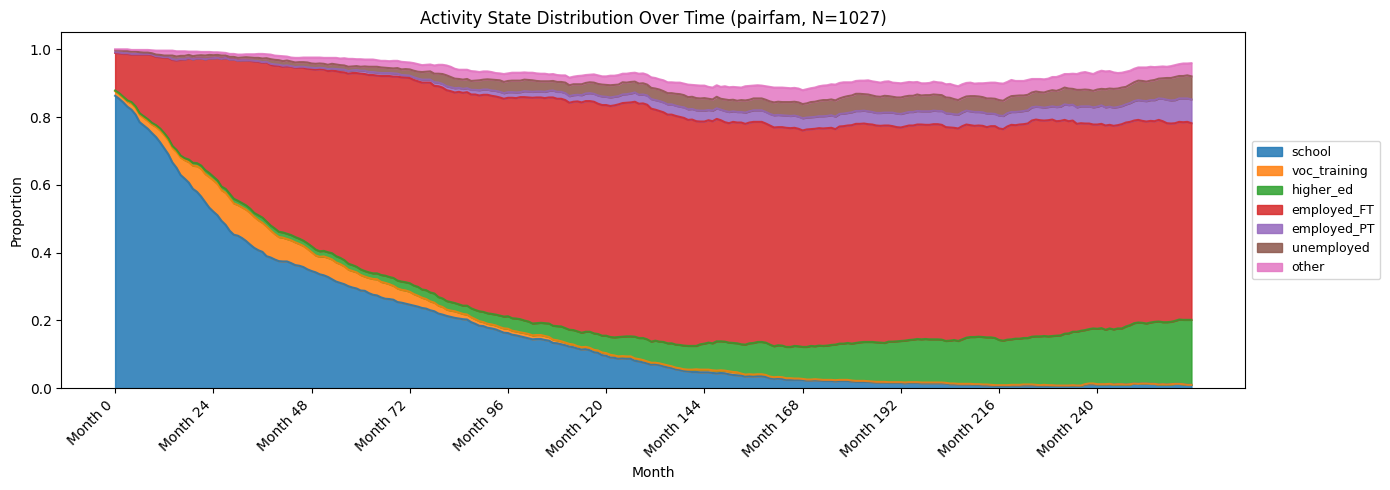

In [7]:
# State distribution over time (using original integer codes for speed)
state_freq = pd.DataFrame()
for t in TIME_COLS:
    counts = df[t].value_counts(normalize=True).sort_index()
    state_freq[t] = counts
state_freq = state_freq.fillna(0).T
state_freq.columns = [state_map[int(c)] for c in state_freq.columns]

fig, ax = plt.subplots(figsize=(14, 5))
state_freq.plot(kind='area', stacked=True, ax=ax, alpha=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('Proportion')
ax.set_title('Activity State Distribution Over Time (pairfam, N=1027)')
ax.set_xticks(range(0, 264, 24))
ax.set_xticklabels([f'Month {i}' for i in range(0, 264, 24)], rotation=45, ha='right')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

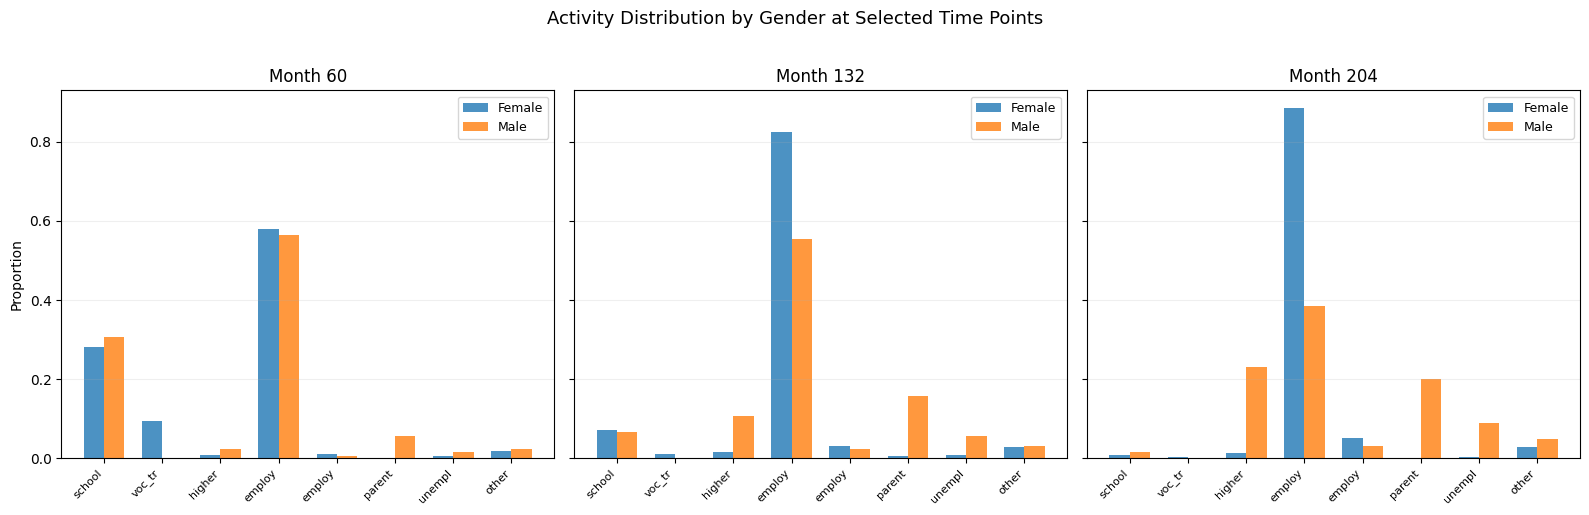

In [8]:
# Compare state distributions by gender at selected time points
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
time_points = {'Month 60': '60', 'Month 132': '132', 'Month 204': '204'}

for ax, (label, t) in zip(axes, time_points.items()):
    female = df[df['sex'] == 0][t].value_counts(normalize=True).sort_index()
    male   = df[df['sex'] == 1][t].value_counts(normalize=True).sort_index()
    
    x = np.arange(8)
    width = 0.35
    ax.bar(x - width/2, [female.get(s, 0) for s in range(1, 9)], width, label='Female', alpha=0.8)
    ax.bar(x + width/2, [male.get(s, 0) for s in range(1, 9)], width, label='Male', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([s[:6] for s in STATES], rotation=45, ha='right', fontsize=8)
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('Proportion')
fig.suptitle('Activity Distribution by Gender at Selected Time Points', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The overall distribution shows a clear life-course pattern:
- Early months are dominated by **school** and **vocational training**.
- **Full-time employment** grows steadily and dominates from about month 60 onward.
- **Parental leave** appears later in the observation window.

The gender comparison reveals visible differences: women show higher proportions in parental leave and part-time employment, while men are more concentrated in full-time employment. This motivates the use of an NHMM to formally test whether gender (and other covariates) significantly affect transition probabilities.

## Step 3: Baseline HMM (no covariates)

Before fitting the NHMM, we first fit a standard HMM as a baseline. This gives us a reference log-likelihood to compare against.

In [9]:
# Fit a standard HMM with 4 hidden states
hmm = build_hmm(seq, n_states=4, random_state=42)
hmm = fit_model(hmm, n_iter=100, tol=1e-2, verbose=True)

print(f"\nBaseline HMM:")
print(f"  logLik:     {hmm.log_likelihood:.2f}")
print(f"  Converged:  {hmm.converged}")
print(f"  Iterations: {hmm.n_iter}")


Baseline HMM:
  logLik:     -243596.39
  Converged:  True
  Iterations: 100


In [10]:
# Examine baseline emission matrix
emission_df = pd.DataFrame(
    hmm.emission_probs,
    index=[f"State {i+1}" for i in range(hmm.n_states)],
    columns=seq.alphabet,
)
print("Baseline HMM Emission Probabilities:")
print(emission_df.round(3))

print("\nDominant activity per hidden state:")
for i in range(hmm.n_states):
    dominant = seq.alphabet[np.argmax(hmm.emission_probs[i])]
    prob = np.max(hmm.emission_probs[i])
    print(f"  State {i+1} -> {dominant} ({prob:.1%})")

Baseline HMM Emission Probabilities:
         school  voc_training  higher_ed  employed_FT  employed_PT  \
State 1   0.000         0.091      0.333        0.000        0.000   
State 2   0.224         0.000      0.000        0.742        0.033   
State 3   0.000         0.088      0.339        0.000        0.000   
State 4   0.222         0.000      0.000        0.745        0.033   

         parental_leave  unemployed  other  
State 1           0.295       0.147  0.134  
State 2           0.000       0.000  0.000  
State 3           0.292       0.148  0.132  
State 4           0.000       0.000  0.000  

Dominant activity per hidden state:
  State 1 -> higher_ed (33.3%)
  State 2 -> employed_FT (74.2%)
  State 3 -> higher_ed (33.9%)
  State 4 -> employed_FT (74.5%)


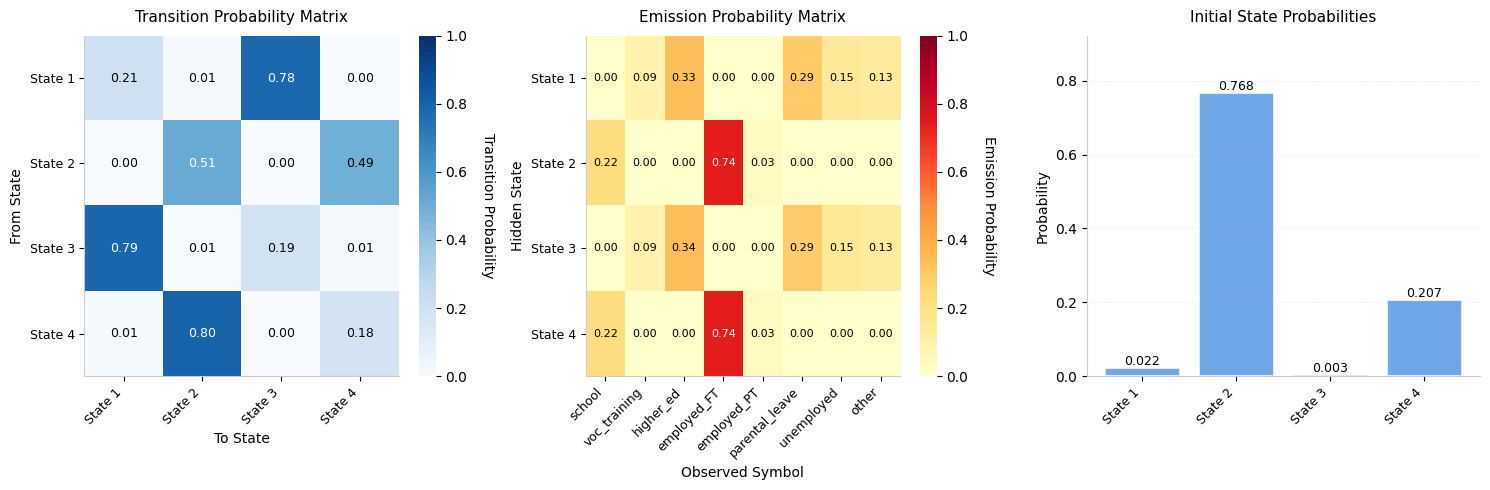

In [11]:
# Visualize baseline HMM
plot_hmm(hmm, which='all', figsize=(15, 5))
plt.tight_layout()
plt.show()

The baseline HMM identifies hidden stages, but it assumes the same transition structure for everyone. The question is: can we do better by letting transitions depend on covariates?

## Step 4: Build and Fit the NHMM

The NHMM extends the standard HMM by modelling transition probabilities as a function of covariates:

- **Standard HMM**: P(state_t | state_{t-1}) = A[i, j] (fixed for all individuals and times)
- **NHMM**: P(state_t | state_{t-1}, x) = softmax(eta_A @ x) (depends on covariates x)

The model estimates coefficient matrices (`eta_pi`, `eta_A`, `eta_B`) that capture how each covariate affects the initial, transition, and emission probabilities respectively.

In [12]:
# Build the NHMM
nhmm = build_nhmm(
    observations=seq,
    n_states=4,
    X=X,  # covariate matrix: (n_seq, n_time, 4)
    random_state=42,
)

print(f"NHMM built:")
print(f"  Hidden states:  {nhmm.n_states}")
print(f"  Covariates:     {nhmm.n_covariates} (intercept + sex + yeduc + east)")
print(f"  Sequences:      {nhmm.n_sequences}")
print(f"  X shape:        {nhmm.X.shape}")

NHMM built:
  Hidden states:  4
  Covariates:     4 (intercept + sex + yeduc + east)
  Sequences:      1027
  X shape:        (1027, 264, 4)


In [14]:
# Check initial log-likelihood before fitting
ll_before = log_likelihood_nhmm(nhmm)
print(f"Log-likelihood before fitting: {ll_before:.2f}")

Could not connect to 127.0.0.1: 50175
Traceback (most recent call last):
  File "/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev/_pydevd_bundle/pydevd_comm.py", line 443, in start_client
    s.connect((host, port))
ConnectionRefusedError: [Errno 61] Connection refused
Traceback (most recent call last):
  File "/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/jupyter_debug/pydev_jupyter_utils.py", line 84, in attach_to_debugger
    debugger.connect(pydev_localhost.get_localhost(), debugger_port)
  File "/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev/pydevd.py", line 688, in connect
    s = start_client(host, port)
  File "/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev/_pydevd_bundle/pydevd_comm.py", line 443, in start_client
    s.connect((host, port))
ConnectionRefusedError: [Errno 61] Connection refused
Failed to connect to target debugger.


In [15]:
# Fit the NHMM using L-BFGS-B optimization
# This may take a few minutes due to the large number of parameters
nhmm = fit_nhmm(nhmm, n_iter=200, tol=1e-6)

print(f"\nNHMM fitted:")
print(f"  logLik:     {nhmm.log_likelihood:.2f}")
print(f"  Converged:  {nhmm.converged}")

KeyboardInterrupt: 

## Step 5: Compare HMM vs NHMM

The key question: does incorporating covariates actually improve the model? We compare the log-likelihoods of the baseline HMM and the NHMM.

In [ ]:
# Compare models
print("Model Comparison:")
print("=" * 55)
print(f"{'Model':<20} {'logLik':>12} {'Improvement':>15}")
print("-" * 55)
print(f"{'Standard HMM':<20} {hmm.log_likelihood:>12.2f} {'(baseline)':>15}")
print(f"{'NHMM (+ covariates)':<20} {nhmm.log_likelihood:>12.2f} "
      f"{nhmm.log_likelihood - hmm.log_likelihood:>+15.2f}")
print("=" * 55)

improvement = nhmm.log_likelihood - hmm.log_likelihood
if improvement > 0:
    print(f"\nThe NHMM improves over the baseline HMM by {improvement:.1f} log-likelihood units,")
    print("suggesting that covariates contribute meaningful information about transitions.")
else:
    print(f"\nThe NHMM does not improve over the baseline HMM.")
    print("The covariates may not strongly affect transition probabilities in this data.")

## Step 6: Interpret the NHMM Coefficients

The NHMM estimates three sets of coefficient matrices:
- `eta_pi`: How covariates affect **initial state** probabilities
- `eta_A`: How covariates affect **transition** probabilities
- `eta_B`: How covariates affect **emission** probabilities

Positive coefficients mean that higher values of the covariate increase the probability of that state/transition; negative coefficients mean they decrease it.

In [ ]:
# Coefficient shapes
print("NHMM coefficient shapes:")
print(f"  eta_pi (initial):    {nhmm.eta_pi.shape}  (n_covariates x n_states)")
print(f"  eta_A  (transition): {nhmm.eta_A.shape}  (n_covariates x n_states x n_states)")
print(f"  eta_B  (emission):   {nhmm.eta_B.shape}  (n_covariates x n_states x n_symbols)")

In [ ]:
# Interpret initial state coefficients
covariate_names = ['intercept', 'sex (male)', 'yeduc (std)', 'east']
state_labels = [f"State {i+1}" for i in range(nhmm.n_states)]

print("Initial State Coefficients (eta_pi):")
print("=" * 60)
eta_pi_df = pd.DataFrame(
    nhmm.eta_pi,
    index=covariate_names,
    columns=state_labels,
)
print(eta_pi_df.round(3))
print("\nInterpretation: Positive values increase the probability of starting in that state.")

In [ ]:
# Visualize transition coefficients for key covariates
# eta_A has shape (n_covariates, n_states, n_states)
# We show the effect of each covariate on transitions

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cov_indices = [1, 2, 3]  # sex, yeduc, east
cov_labels = ['Sex (male)', 'Education (std)', 'East Germany']

for ax, cov_idx, cov_label in zip(axes, cov_indices, cov_labels):
    eta_slice = nhmm.eta_A[cov_idx]  # (n_states, n_states)
    im = ax.imshow(eta_slice, cmap='RdBu_r', aspect='auto',
                   vmin=-np.abs(eta_slice).max(), vmax=np.abs(eta_slice).max())
    ax.set_xticks(range(nhmm.n_states))
    ax.set_yticks(range(nhmm.n_states))
    ax.set_xticklabels(state_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(state_labels, fontsize=9)
    ax.set_xlabel('To')
    ax.set_ylabel('From')
    ax.set_title(f'Effect of {cov_label}')
    
    for i in range(nhmm.n_states):
        for j in range(nhmm.n_states):
            ax.text(j, i, f'{eta_slice[i,j]:.2f}', ha='center', va='center', fontsize=8)

fig.suptitle('Transition Coefficients (eta_A): How Covariates Affect Transitions',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation: Blue = covariate decreases transition probability; "
      "Red = covariate increases it.")

### Answering Research Question 2: Do covariates affect transitions?

By examining the transition coefficient heatmaps above:

- **Sex (male)**: Look for large positive or negative values. If the male coefficient is negative for transitions into a "parental leave" state and positive for transitions into "full-time employment", this confirms a gendered pattern.
- **Education**: Higher education may increase transitions into certain states (e.g., higher education to employment) while decreasing others (e.g., direct entry into vocational training).
- **East Germany**: Historical differences in labour markets may show up as different transition patterns, such as higher transitions into unemployment.

The magnitude of the coefficients tells us the strength of each effect, and the sign tells us the direction. Even if some effects are small, the overall improvement in log-likelihood (Step 5) confirms whether covariates collectively contribute meaningful information.

Note: The exact interpretation depends on the fitted values. Inspect the heatmaps and coefficient tables above to draw specific conclusions from your run.

## Step 7: Model Selection

As with the standard HMM, we can compare NHMMs with different numbers of hidden states.

In [ ]:
# Compare NHMMs with 3, 4, 5 states
results = []
for n in [3, 4, 5]:
    print(f"Fitting {n}-state NHMM...")
    h = build_nhmm(observations=seq, n_states=n, X=X, random_state=42)
    h = fit_nhmm(h, n_iter=200, tol=1e-6)
    results.append({
        'n_states': n,
        'logLik': h.log_likelihood,
    })
    print(f"  logLik = {h.log_likelihood:.1f}")

results_df = pd.DataFrame(results)
print("\nNHMM model comparison:")
print(results_df.to_string(index=False))

In [ ]:
# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results_df['n_states'], results_df['logLik'], 'o-',
        linewidth=2, markersize=8, color='#4A90E2')
ax.set_xlabel('Number of hidden states')
ax.set_ylabel('Log-likelihood (higher is better)')
ax.set_title('NHMM Model Comparison')
ax.set_xticks([3, 4, 5])
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Summary

In this tutorial, we applied a **Non-Homogeneous HMM** to the pairfam activity dataset (1027 individuals, 264 months, 8 activity states, 3 covariates).

### What we found

**Hidden stages (baseline HMM):** The standard HMM identified activity stages such as education, employment, and mixed/transitional phases, with high persistence within each stage.

**Covariate effects (NHMM):** By incorporating gender, education level, and East/West Germany as covariates, the NHMM allows us to test whether these characteristics shape how people transition between activity stages. The comparison of log-likelihoods tells us whether covariates collectively improve the model. The coefficient matrices reveal the direction and strength of each covariate's effect on specific transitions.

### What makes NHMM different from HMM and MHMM

| Model | Transition probabilities | What it finds |
|-------|-------------------------|---------------|
| HMM | Fixed for everyone | Hidden stages, shared by all |
| MHMM | Different per cluster | Discrete types of trajectories |
| NHMM | Depend on covariates | How individual characteristics shape transitions |

The NHMM is the most flexible of the three: rather than grouping people into discrete types (MHMM), it models a continuous relationship between covariates and transition dynamics.

### Workflow recap

| Step | What we did | Key function |
|------|-------------|-------------|
| Data preparation | Loaded sequences + built covariate matrix X | `SequenceData()` + numpy |
| Exploratory visualization | State distribution over time; gender comparison | matplotlib |
| Baseline HMM | Fitted standard HMM as reference | `build_hmm()`, `fit_model()` |
| NHMM building | Specified covariates (sex, education, region) | `build_nhmm()` |
| NHMM fitting | L-BFGS-B optimization | `fit_nhmm()` |
| Model comparison | HMM vs NHMM log-likelihood; 3-5 state comparison | log-likelihood |
| Coefficient interpretation | Transition coefficient heatmaps | matplotlib |
